In [10]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from combat.pycombat import pycombat
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# 1. Read in the data
## 1.1 Batch 1

In [11]:
# Read the cell, nuclei and nucleolei files from batch 1
cell_batch1 = pd.read_csv("Confocal_40X_20px_cells.csv")

# Nuclei info
nuclei_batch1 = pd.read_csv("Confocal_40x_20px_nuclei.csv")
nuclei_batch1.columns = ["Nucleus_" + name for name in nuclei_batch1.columns] # to avoid duplicate names from the different files

# Nucleolei info (since not every cell has a nucleolus, we can merge this information only on a field-of-view level)
nucleolei_batch1 = pd.read_csv("Confocal_40x_20px_Nucleolei.csv")
nucleolei_batch1["Metadata_Plate"] = "1"
nucleolei_batch1.columns = [
    name if "Metadata" in name or name in ["ImageNumber", "ObjectNumber"] 
    else "Nucleolei_" + name 
    for name in nucleolei_batch1.columns
]

all_batch1 = pd.concat([cell_batch1, nuclei_batch1], axis=1)
all_batch1["Metadata_Plate"] = "1"

# Assign the cell line information for Plate 1
unique_values = all_batch1["Metadata_Well"].unique() 

cell_line_info = {
    "E01": "JHOS2",
    "E02": "JHOS2",
    "E03": "JHOS2",
    "E04": "JHOS2",
    "E05": "Kuramochi",
    "E06": "Kuramochi",
    "E07": "Ovsaho",
    "E08": "COV318",
    "E09": "COV318",
    "E10": "COV362"
}

treatment_info = {
    "E01": "PTX",
    "E02": "PTX",
    "E03": "AZD1775",
    "E04": "AZD1775",
    "E05": "parental",
    "E06": "AZD1775",
    "E07": "AZD1775",
    "E08": "parental",
    "E09": "PTX",
    "E10": "parental"
}

concentration_info = { 
    "E01": "50 nM",
    "E02": "150 nM",
    "E03": "1 µM",
    "E04": "2 µM",
    "E05": "none",
    "E06": "2 µM",
    "E07": "1.5 µM",
    "E08": "none",
    "E09": "750 nM",
    "E10": "none"
}

cell_line_mapping = {}
treatment_mapping = {}
concentration_mapping = {}

for value in unique_values:
    cell_line_mapping[value] = cell_line_info.get(value, None)
    treatment_mapping[value] = treatment_info.get(value, None)
    concentration_mapping[value] = concentration_info.get(value, None)
all_batch1["CellLine"] = all_batch1["Metadata_Well"].map(lambda x: cell_line_mapping.get(x, None))
all_batch1["Treatment"] = all_batch1["Metadata_Well"].map(lambda x: treatment_mapping.get(x, None))
all_batch1["Concentration"] = all_batch1["Metadata_Well"].map(lambda x: concentration_mapping.get(x, None))
all_batch1["Condition"] = all_batch1.apply(lambda row: f"{row['CellLine']} parental" if row['Treatment'] == "parental" else f"{row['CellLine']} {row['Treatment']}res", axis=1)
all_batch1["Condition_Concentration_Plate"] = all_batch1.apply(lambda row: f"{row['Condition']}_{row['Concentration']}_{row['Metadata_Plate']}", axis = 1) 
all_batch1["Number_of_Nucleolei"] = all_batch1["Nucleus_Children_Nucleolei_Count"]

nucleolei_batch1["CellLine"] = nucleolei_batch1["Metadata_Well"].map(lambda x: cell_line_mapping.get(x, None))
nucleolei_batch1["Treatment"] = nucleolei_batch1["Metadata_Well"].map(lambda x: treatment_mapping.get(x, None))
nucleolei_batch1["Concentration"] = nucleolei_batch1["Metadata_Well"].map(lambda x: concentration_mapping.get(x, None))
nucleolei_batch1["Condition"] = nucleolei_batch1.apply(lambda row: f"{row['CellLine']} parental" if row['Treatment'] == "parental" else f"{row['CellLine']} {row['Treatment']}res", axis=1)
nucleolei_batch1["Condition_Concentration_Plate"] = nucleolei_batch1.apply(lambda row: f"{row['Condition']}_{row['Concentration']}_{row['Metadata_Plate']}", axis = 1) 

## 1.1 Batch 2

In [12]:
# Read the cell, nuclei and nucleolei files from batch 2
cell_batch2 = pd.read_csv("Batch2_Confocal_40X_cells.csv")

# Nuclei info
nuclei_batch2 = pd.read_csv("Batch2_Confocal_40x_nuclei.csv")
nuclei_batch2.columns = ["Nucleus_" + name for name in nuclei_batch2.columns]

# Nucleolei info
nucleolei_batch2 = pd.read_csv("Batch2_Confocal_40x_Nucleolei.csv")
nucleolei_batch2["Metadata_Plate"] = "2"
nucleolei_batch2.columns = [
    name if "Metadata" in name or name in ["ImageNumber", "ObjectNumber"] 
    else "Nucleolei_" + name 
    for name in nucleolei_batch2.columns
]

all_batch2 = pd.concat([cell_batch2, nuclei_batch2], axis=1)
all_batch2["Metadata_Plate"] = "2"

# Assign the cell line information for Batch 2
unique_values = all_batch2["Metadata_Well"].unique() 

cell_line_info = {
    "B02": "JHOS2",
    "B03": "JHOS2",
    "B04": "JHOS2",
    "B05": "Kuramochi",
    "B06": "Kuramochi",
    "B07": "Ovsaho",
    "B08": "Ovsaho",
}

treatment_info = {
    "B02": "parental",
    "B03": "AZD1775",
    "B04": "PTX",
    "B05": "parental",
    "B06": "AZD1775",
    "B07": "parental",
    "B08": "AZD1775",
}

concentration_info = { 
    "B02": "none",
    "B03": "1 µM",
    "B04": "50 nM",
    "B05": "none",
    "B06": "2 µM",
    "B07": "none",
    "B08": "1.5 µM",
}

cell_line_mapping = {}
treatment_mapping = {}
concentration_mapping = {}

for value in unique_values:
    cell_line_mapping[value] = cell_line_info.get(value, None)
    treatment_mapping[value] = treatment_info.get(value, None)
    concentration_mapping[value] = concentration_info.get(value, None)
all_batch2["CellLine"] = all_batch2["Metadata_Well"].map(lambda x: cell_line_mapping.get(x, None))
all_batch2["Treatment"] = all_batch2["Metadata_Well"].map(lambda x: treatment_mapping.get(x, None))
all_batch2["Concentration"] = all_batch2["Metadata_Well"].map(lambda x: concentration_mapping.get(x, None))
all_batch2["Condition"] = all_batch2.apply(lambda row: f"{row['CellLine']} parental" if row['Treatment'] == "parental" else f"{row['CellLine']} {row['Treatment']}res", axis=1)
all_batch2["Condition_Concentration_Plate"] = all_batch2.apply(lambda row: f"{row['Condition']}_{row['Concentration']}_{row['Metadata_Plate']}", axis = 1)
all_batch2["Number_of_Nucleolei"] = all_batch2["Nucleus_Children_Nucleolei_Count"]

nucleolei_batch2["CellLine"] = nucleolei_batch2["Metadata_Well"].map(lambda x: cell_line_mapping.get(x, None))
nucleolei_batch2["Treatment"] = nucleolei_batch2["Metadata_Well"].map(lambda x: treatment_mapping.get(x, None))
nucleolei_batch2["Concentration"] = nucleolei_batch2["Metadata_Well"].map(lambda x: concentration_mapping.get(x, None))
nucleolei_batch2["Condition"] = nucleolei_batch2.apply(lambda row: f"{row['CellLine']} parental" if row['Treatment'] == "parental" else f"{row['CellLine']} {row['Treatment']}res", axis=1)
nucleolei_batch2["Condition_Concentration_Plate"] = nucleolei_batch2.apply(lambda row: f"{row['Condition']}_{row['Concentration']}_{row['Metadata_Plate']}", axis = 1) 

In [13]:
# Functions
def prepare_and_scale(dfs, ret_non_num=False):
    # If dfs is not a list, convert it to a list
    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]

    # Initialize lists to store processed numerical and non-numerical dataframes
    info_num_list = []
    info_non_numerical_list = []

    # Iterate over the list of dataframes
    for df in dfs:
        # Data preparation
        # Filter out NA values
        df = df.dropna(axis=1, how="any")  # drop all columns with at least one NA value
        df_raw = df.filter(regex="^(?!.*Metadata).*").drop(["ImageNumber", "ObjectNumber"], axis=1)  # Filter out metadata
        df_info_num = df_raw.select_dtypes(include=["number"])  # Split the remaining columns into numerical
        df_info_non_num = df.select_dtypes(exclude=["number"])  # and non-numerical
        df_info_non_num = pd.concat([df_info_non_num, df[["Metadata_Well", "Metadata_Site"]]])

        # Get the mean values for each field of view (25 per well)
        info_num = df.groupby(["Metadata_Plate", "Metadata_Well", "Metadata_Site"])[df_info_num.columns].mean().reset_index()
        info_non_numerical = df.groupby(["Metadata_Plate", "Metadata_Well", "Metadata_Site"]).first().reset_index()[df_info_non_num.columns]
        
        # Store the processed dataframes in the lists
        info_num_list.append(info_num)
        info_non_numerical_list.append(info_non_numerical)

    # If there's only one dataframe, no need to merge, just use it directly
    if len(dfs) == 1:
        merged_fov_info_num = info_num_list[0]
        merged_fov_info_non_numerical = info_non_numerical_list[0]

    else:
        # Merge the numerical and non-numerical dataframes by "Metadata_Plate", "Metadata_Well", "Metadata_Site"
        merged_fov_info_num = info_num_list[0]
        merged_fov_info_non_numerical = info_non_numerical_list[0]
        
        for i in range(1, len(dfs)):
            merged_fov_info_num = pd.merge(merged_fov_info_num, info_num_list[i], on=["Metadata_Plate", "Metadata_Well", "Metadata_Site"])
            merged_fov_info_non_numerical = pd.merge(merged_fov_info_non_numerical, info_non_numerical_list[i], on=["Metadata_Plate", "Metadata_Well", "Metadata_Site"], how="outer", suffixes=("", "_drop"))
            merged_fov_info_non_numerical = merged_fov_info_non_numerical.loc[:, ~merged_fov_info_non_numerical.columns.str.endswith("_drop")]

    # Scale the merged data
    scaler = StandardScaler()
    mean_data_scaled = scaler.fit_transform(merged_fov_info_num.drop(columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"]))
    
    # Feature Selection
    sel = VarianceThreshold(threshold=1)
    mean_scaled_sel = pd.DataFrame(sel.fit_transform(mean_data_scaled))
    features_sel = sel.get_feature_names_out(merged_fov_info_num.columns.drop(["Metadata_Plate", "Metadata_Well", "Metadata_Site"]))

    # Feature selection and data scaling
    fov_info_num_sel = merged_fov_info_num[["Metadata_Plate", "Metadata_Well", "Metadata_Site"] + list(features_sel)]  # Keep Plate, Well, Site columns
    scaler = StandardScaler()  # Scale the feature-selected data as well
    data_scaled_fovs = scaler.fit_transform(fov_info_num_sel.drop(columns=["Metadata_Plate", "Metadata_Well", "Metadata_Site"]))

    if not ret_non_num:
        return data_scaled_fovs, merged_fov_info_non_numerical
    else:
        return data_scaled_fovs, merged_fov_info_non_numerical, features_sel

def plot_umaps(scaled_df, df_info_non_num, save = None, chosen_column = "Condition"):
    # Takes in the scaled_df, the non-numerical info and the title of the figures should they be saved
    mapper = umap.UMAP(random_state=42).fit_transform(scaled_df) # Generate the field-of-view UMAPs
    
    # Define the color scheme
    if chosen_column == "Condition":
        cell_line_colors = {
            "JHOS2 PTXres": "#7b51df",
            "JHOS2 AZD1775res": "#ddd3f7",
            "Kuramochi parental": "#2281E2",
            "Kuramochi AZD1775res": "#7CD1EE",
            "Ovsaho AZD1775res": "#c6e6a4",
            "COV318 parental": "#f49aa3",
            "COV318 PTXres": "#de182b",
            "COV362 parental": "#FFCE54",
            "JHOS2 parental": "#ac92eb",
            "Ovsaho parental": "#7abc34"
        }
    elif chosen_column == "Condition_Concentration_Plate":
        cell_line_colors = {
            "JHOS2 parental_none_2": "#fdca54",
            "JHOS2 AZD1775res_1 µM_2": "#f08ab1",
            "JHOS2 PTXres_50 nM_2": "#f6a570",
            "Kuramochi parental_none_2": "#927db6",
            "Kuramochi AZD1775res_2 µM_2": "#5da0d7",
            "Ovsaho parental_none_2": "#fee327",
            "Ovsaho AZD1775res_1.5 µM_2": "#00b3e1",
            "JHOS2 PTXres_50 nM_1": "#f7b27a",
            "JHOS2 PTXres_150 nM_1": "#f1969b",
            "JHOS2 AZD1775res_1 µM_1": "#f08ab1",
            "JHOS2 AZD1775res_2 µM_1": "#c78dbd",
            "Kuramochi parental_none_1": "black",
            "Kuramochi AZD1775res_2 µM_1": "#5da0d7",
            "Ovsaho AZD1775res_1.5 µM_1": "#00b3e1",
            "COV318 parental_none_1": "brown",
            "COV318 PTXres_750 nM_1": "#65bda5",
            "COV362 parental_none_1": "red"
        }
    
    # Ensure that the color map uses your predefined color encoding
    condition_to_color = {cond: cell_line_colors[cond] for cond in df_info_non_num[chosen_column].unique() if cond in cell_line_colors}
    
    # Check if all conditions have a defined color
    missing_conditions = set(df_info_non_num[chosen_column].unique()) - set(condition_to_color.keys())
    if missing_conditions:
        print(f"Warning: The following conditions are missing color definitions: {missing_conditions}")
 
    # Generate the color lists
    colors_list = [condition_to_color[line] for line in df_info_non_num[chosen_column]]
    
    # Plot the UMAP
    plt.figure(figsize=(5, 5))  # Larger figure to accommodate more colors
    for i, line in enumerate(df_info_non_num[chosen_column]):
        plt.scatter(mapper[i, 0], mapper[i, 1], c=[colors_list[i]], s=10)
    
    # Create dummy scatter plot objects with labels for each category for the legend
    for label in df_info_non_num[chosen_column].unique():
        plt.scatter([], [], color=condition_to_color[label], label=label)
    
    plt.legend(framealpha=0.5, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.axis("off")
    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams['pdf.fonttype'] = 42
    if save != None:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    plt.show()

# 2. Batch correction using combat

In [14]:
# We first merge the cell + nuclei with the nucleolei information using the mean per field of view
# The dataframes will be combined as part of the "prepare_and_scale" function after getting the mean features and before scaling
all_both = pd.concat([all_batch1, all_batch2], axis=0, ignore_index=True)
all_both = all_both[all_both["CellLine"] != "COV362"]
nucleolei_both = pd.concat([nucleolei_batch1, nucleolei_batch2], axis=0, ignore_index=True)
nucleolei_both = nucleolei_both[nucleolei_both["CellLine"] != "COV362"]

data_scaled_all_all, fov_info_non_numerical_all, features_sel_all = prepare_and_scale([all_both, nucleolei_both], True)

# Batch correction using combat
batch_all = fov_info_non_numerical_all["Metadata_Plate"].values
data_scaled_all = pd.DataFrame(data_scaled_all_all, columns=features_sel_all).T
batch_corrected_all = pycombat(data_scaled_all, batch_all).T

Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


## 2.1 UMAPs after batch correction
### 2.4.1 UMAPs after batch correction - AZD samples only

C:\Python3115\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


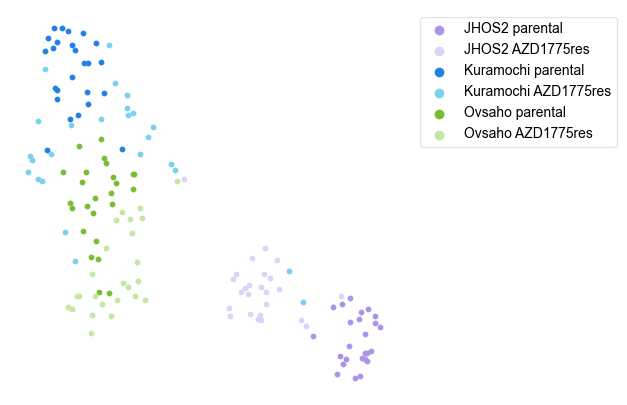

In [15]:
# Use all the data (cell, nuclei and nucleolei)
# Define the conditions for filtering based on CellLine and Plate
conditions = (
    ((fov_info_non_numerical_all['CellLine'].isin(["JHOS2", "Kuramochi", "Ovsaho"])) & (fov_info_non_numerical_all['Metadata_Plate'] == "2")) |
    ((fov_info_non_numerical_all['CellLine'].isin(["COV318"])) & (fov_info_non_numerical_all['Metadata_Plate'] == "1"))
)
treatment_condition = fov_info_non_numerical_all["Treatment"].isin(["parental", "AZD1775"]) # Add the condition to keep only rows where "Treatment" is "parental" or "AZD1775"
combined_conditions = conditions & treatment_condition # Combine the conditions

# Filter the dataframe for which we have both "parental" and "AZD1775" treatments
filtered_df = fov_info_non_numerical_all[combined_conditions]
valid_cell_lines = filtered_df.groupby('CellLine').filter(lambda x: set(x['Treatment']) == {'parental', 'AZD1775'})['CellLine'].unique()
final_filtered_df = filtered_df[filtered_df['CellLine'].isin(valid_cell_lines)]

# Subset batch_corrected and fov_info_non_numerical_both using the indices from the final_filtered_df
sel_cell_lines_batch_corrected = batch_corrected_all.loc[final_filtered_df.index]
fov_info_non_numerical_cl = fov_info_non_numerical_all.loc[final_filtered_df.index]

# Generate the UMAP plots with the filtered data
plot_umaps(
    sel_cell_lines_batch_corrected, fov_info_non_numerical_cl,
    "UMAPs after batch correction_AZD only_all_condition.pdf",
    "Condition"
)

### 2.4.1 UMAPs after batch correction - PTX samples only

C:\Python3115\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


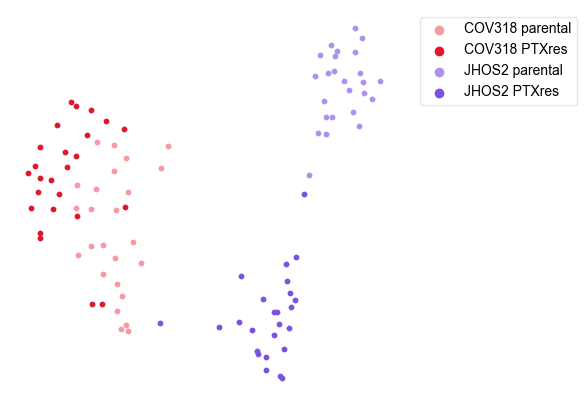

In [19]:
# Using the combined cell, nucleus and nucleolus features
# Define the conditions for filtering based on CellLine and Plate
conditions = (
    ((fov_info_non_numerical_all['CellLine'].isin(["JHOS2", "Kuramochi", "Ovsaho"])) & (fov_info_non_numerical_all['Metadata_Plate'] == "2")) |
    ((fov_info_non_numerical_all['CellLine'].isin(["COV318"])) & (fov_info_non_numerical_all['Metadata_Plate'] == "1"))
)

# Filter the condition to keep only rows where "Treatment" is "parental" or "AZD1775"
treatment_condition = fov_info_non_numerical_all["Treatment"].isin(["parental", "PTX"])
combined_conditions = conditions & treatment_condition
filtered_df = fov_info_non_numerical_all[combined_conditions]

# Filter cell lines that have both "parental" and "AZD1775" treatments
valid_cell_lines = filtered_df.groupby("CellLine").filter(lambda x: set(x["Treatment"]) == {"parental", "PTX"})["CellLine"].unique()
final_filtered_df = filtered_df[filtered_df["CellLine"].isin(valid_cell_lines)]

# Subset batch_corrected and fov_info_non_numerical_both using the indices from the final_filtered_df
sel_cell_lines_batch_corrected = batch_corrected_all.loc[final_filtered_df.index]
fov_info_non_numerical_cl = fov_info_non_numerical_all.loc[final_filtered_df.index]

desired_order = ["JHOS2 parental", "JHOS2 PTXres", "COV318 parental", "COV318 PTXres"] # Set the desired order for the combined categories
# Convert the new column to a categorical type with the specified order
fov_info_non_numerical_cl["Condition"] = pd.Categorical(fov_info_non_numerical_cl["Condition"], categories=desired_order, ordered=True)

# Generate the UMAP plots with the filtered data
plot_umaps(
    sel_cell_lines_batch_corrected, fov_info_non_numerical_cl,
    "UMAPs after batch correction_PTX only_all_condition.pdf",
    "Condition"
)

# 3. Compare the number of nucleolei in each condition with their respective control
- we (statistically) compare only samples and treatments from the same plate

In [20]:
# Define the conditions to include
plate_1_cell_lines = ["COV318", "COV362"]
plate_2_cell_lines = ["JHOS2", "Kuramochi", "Ovsaho"]

# Create a mask to filter the DataFrame
mask_batch_1 = (all_both["CellLine"].isin(plate_1_cell_lines)) & (all_both["Metadata_Plate"] == "1")
mask_batch_2 = (all_both["CellLine"].isin(plate_2_cell_lines)) & (all_both["Metadata_Plate"] == "2")
sel_cell_lines_before = all_both[mask_batch_1 | mask_batch_2] # Filter the DataFrame
# Generate features to be able to make a stack plot of the Nucleus/Cytoplasm protportions
sel_cell_lines_before.loc[:, "Cytoplasm_Area"] = sel_cell_lines_before["AreaShape_Area"] - sel_cell_lines_before["Nucleus_AreaShape_Area"]
sel_cell_lines_before.loc[:, "Cytoplasm_Area_Rel"] = sel_cell_lines_before["Cytoplasm_Area"] / sel_cell_lines_before["AreaShape_Area"]

sel_cell_lines_meta = sel_cell_lines_before[["Metadata_Plate", "Metadata_Well", "Metadata_Site", "Treatment", "Condition", "CellLine", "Neighbors_NumberOfNeighbors_20", "Cytoplasm_Area_Rel"]]  # The metadata we are actually interested in
sel_cells_fov_median = sel_cell_lines_before.groupby(["Metadata_Plate", "Metadata_Well", "Metadata_Site"])["Number_of_Nucleolei"].mean().reset_index()
sel_cells_fov_meta = sel_cell_lines_before.groupby(["Metadata_Plate", "Metadata_Well", "Metadata_Site"]).first().reset_index()[sel_cell_lines_meta.columns]
sel_cell_lines_all = pd.merge(sel_cells_fov_median, sel_cells_fov_meta, on=["Metadata_Plate", "Metadata_Well", "Metadata_Site"]) # We first get the FOV mean and then filter

# AZD
azd_mask = sel_cell_lines_all["Treatment"].isin(["parental", "AZD1775"]) # Filter by parental and AZD1775
sel_cell_lines_AZD = sel_cell_lines_all[azd_mask]

# PTX
ptx_mask = sel_cell_lines_all["Treatment"].isin(["parental", "PTX"])
sel_cell_lines_PTX = sel_cell_lines_all[ptx_mask]

C:\Users\fbirk\AppData\Local\Temp\ipykernel_1448\1407071682.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_cell_lines_before.loc[:, "Cytoplasm_Area"] = sel_cell_lines_before["AreaShape_Area"] - sel_cell_lines_before["Nucleus_AreaShape_Area"]
C:\Users\fbirk\AppData\Local\Temp\ipykernel_1448\1407071682.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_cell_lines_before.loc[:, "Cytoplasm_Area_Rel"] = sel_cell_lines_before["Cytoplasm_Area"] / sel_cell_lines_before["AreaShape_Area"]


JHOS2 parental vs JHOS2 AZD1775res): p-value = 0.27946363514442185
Kuramochi parental vs Kuramochi AZD1775res): p-value = 0.9044550585527283
Ovsaho parental vs Ovsaho AZD1775res): p-value = 0.139563596966666


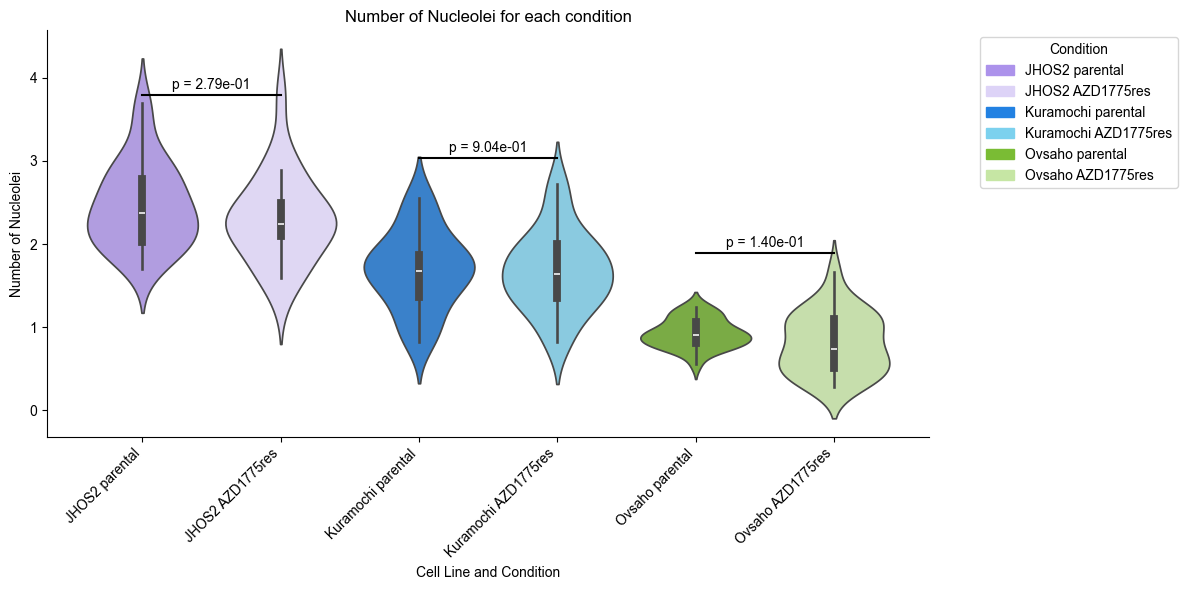

In [21]:
# Plot the AZD condition
sel_cell_lines = sel_cell_lines_AZD.copy()

# Function to find a new y position from the list
def get_y_position(max_value):
    y_pos = next(y for y in y_values if y > max_value) # Find the y_value that is just above the max_value
    y_values.remove(y_pos) # Remove the used y-value from the list
    return y_pos

# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 AZD1775res": "#ddd3f7",
    "Kuramochi parental": "#2281E2",
    "Kuramochi AZD1775res": "#7CD1EE",
    "Ovsaho AZD1775res": "#c6e6a4",
    "JHOS2 parental": "#ac92eb",
    "Ovsaho parental": "#7abc34"
}

custom_order = ["JHOS2 parental", "JHOS2 AZD1775res",
                "Kuramochi parental", "Kuramochi AZD1775res",
                "Ovsaho parental", "Ovsaho AZD1775res"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()] # Filter the custom order to only include conditions present in the data
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True) # Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend

# Plot the boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Number_of_Nucleolei", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Number of Nucleolei")
plt.title("Number of Nucleolei for each condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Number_of_Nucleolei"].max()
y_values = np.arange(0, max_y + 20, 0.1 * max_y).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Number_of_Nucleolei"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Number_of_Nucleolei"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y  # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Number of nucleolei_sel_cell_lines_Adjacent_FOV mean_AZD.pdf", dpi=300, bbox_inches="tight")
plt.show()

COV318 parental vs COV318 PTXres): p-value = 0.14862761933194266
JHOS2 parental vs JHOS2 PTXres): p-value = 1.4274511972911097e-09


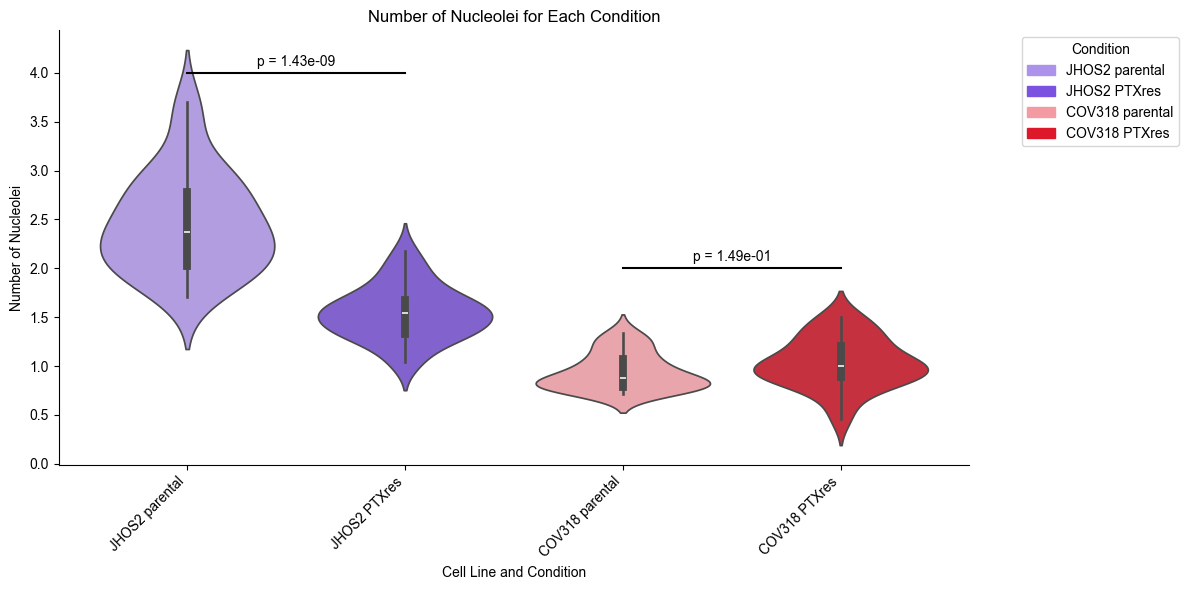

In [22]:
# Plot the PTX condition
sel_cell_lines = sel_cell_lines_PTX.copy()

# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 PTXres": "#7b51df",
    "COV318 parental": "#f49aa3",
    "COV318 PTXres": "#de182b",
    "JHOS2 parental": "#ac92eb"
}

custom_order = ["JHOS2 parental", "JHOS2 PTXres",
                "COV318 parental", "COV318 PTXres"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

# Filter the custom order to only include conditions present in the data
custom_order = [cond for cond in custom_order if cond in sel_cell_lines["Condition"].unique()]

# Update sel_cell_lines["Condition"] to ensure the same order as the sorted legend
sel_cell_lines["Condition"] = pd.Categorical(sel_cell_lines["Condition"], categories=custom_order, ordered=True)

# Plot the boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(x="Condition", y="Number_of_Nucleolei", hue="Condition", data=sel_cell_lines, palette=sorted_colors)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Cell Line and Condition")
plt.ylabel("Number of Nucleolei")
plt.title("Number of Nucleolei for Each Condition")

# Create the custom legend with sorted titles
handles = [plt.Rectangle((0, 0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
sns.despine()  # Remove the top and right spines (borders)

# Initialize a list of y-values in steps of 2.5 up to the maximum observed value in the dataframe
max_y = sel_cell_lines["Number_of_Nucleolei"].max()
y_values = np.arange(0, max_y + 20, 1).tolist()

processed_comparisons = set()  # Initialize a set to keep track of processed comparisons

# Perform paired t-tests with the control samples and annotate
for cell_line in sel_cell_lines["CellLine"].unique():
    control_condition = cell_line + " " + "parental"
    control_data = sel_cell_lines[sel_cell_lines["Condition"] == control_condition]["Number_of_Nucleolei"]

    if len(control_data) <= 1:
        continue

    for condition in sel_cell_lines[sel_cell_lines["CellLine"] == cell_line]["Condition"].unique():
        if condition == control_condition:
            continue
        treatment_data = sel_cell_lines[sel_cell_lines["Condition"] == condition]["Number_of_Nucleolei"]

        if len(treatment_data) > 1:
            comparison_key = (control_condition, condition)
            if comparison_key in processed_comparisons:
                continue
            processed_comparisons.add(comparison_key)

            t_stat, p_value = ttest_ind(control_data.values, treatment_data.values, equal_var=False)
            print(f"{control_condition} vs {condition}): p-value = {p_value}")

            # Get positions for control and treatment conditions
            control_pos = custom_order.index(control_condition)
            treatment_pos = custom_order.index(condition)

            # Get a unique y position
            y_max = max(control_data.max(), treatment_data.max())
            new_y_pos = get_y_position(y_max)

            # Draw line
            plt.plot([control_pos, treatment_pos], [new_y_pos, new_y_pos], color="black")

            # Annotate p-value with an additional offset for text
            text_offset = 0.02 * max_y # Adjust this value as needed for higher placement
            mid_pos = (control_pos + treatment_pos) / 2
            plt.text(mid_pos, new_y_pos + text_offset, f"p = {p_value:.2e}", ha="center")

# Save the figure
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Violinplots_Number of nucleolei_sel_cell_lines_Adjacent_FOV mean_PTX.pdf", dpi=300, bbox_inches="tight")
plt.show()

# 4. Neighbor plots

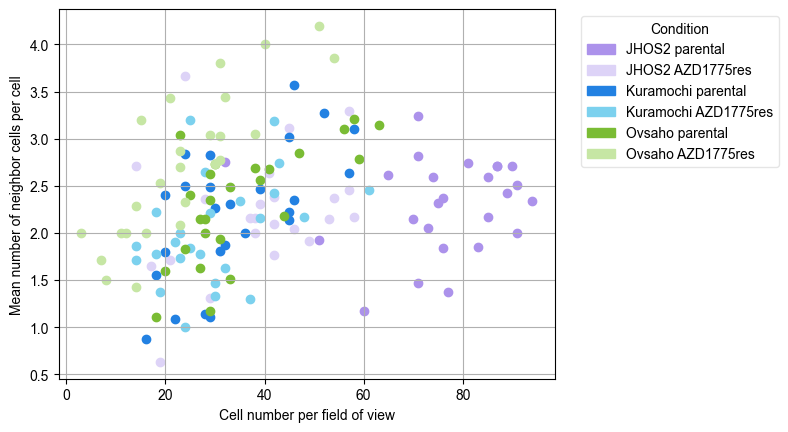

In [29]:
# Prepare data to get the neighbor information for each cell line or field of view
# Each cell within 20 pixels of another cell is considered a neighbor cell
# this is done on a field of view level
# For AZD treatment
cell_line_colors = {
    "JHOS2 AZD1775res": "#ddd3f7",
    "Kuramochi parental": "#2281E2",
    "Kuramochi AZD1775res": "#7CD1EE",
    "Ovsaho AZD1775res": "#c6e6a4",
    "JHOS2 parental": "#ac92eb",
    "Ovsaho parental": "#7abc34"
}

custom_order = ["JHOS2 parental", "JHOS2 AZD1775res",
                "Kuramochi parental", "Kuramochi AZD1775res",
                "Ovsaho parental", "Ovsaho AZD1775res"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

azd_mask = sel_cell_lines_before["Condition"].isin(custom_order) # Filter by parental and AZD1775
sel_cell_lines_AZD_neighbor = sel_cell_lines_before[azd_mask]

# Prepare data to get the neighbor information for each field of view
col_names = ["Condition", "Number of cells", "Number of neighbors per cell", "Total number of neighbors"]        
grouped_c_fov = sel_cell_lines_AZD_neighbor.groupby(["CellLine", "Metadata_Well", "Metadata_Site"])
cell_num_fov = grouped_c_fov.size()
neighbor_num_fov = grouped_c_fov["Neighbors_NumberOfNeighbors_20"].mean() # gets the mean number of neighbor cells
neighbor_sum_fov = grouped_c_fov["Neighbors_NumberOfNeighbors_20"].sum() # gets the sum of neighbor cells in total
conditions = grouped_c_fov["Condition"].first()
int_feat_fov = pd.concat([conditions, cell_num_fov, neighbor_num_fov, neighbor_sum_fov], axis=1, keys=col_names).reset_index()

# Reuse the cell_line_colors dictionary from the previous plots
colors = [cell_line_colors[line] for line in int_feat_fov["Condition"]] # generate a list of colors
sorted_colors = dict(sorted(cell_line_colors.items())) # Sorting cell line colors for legend

for i, (cell_num, neighbor_num, label, color) in enumerate(zip(int_feat_fov["Number of cells"], int_feat_fov["Number of neighbors per cell"], int_feat_fov["Condition"], colors)):
    plt.scatter(cell_num, neighbor_num, c=color)
for label, color in sorted_colors.items(): # Create dummy scatter plot objects with labels for each category for the legend
    plt.scatter([], [], color=color, label=label)

handles=[plt.Rectangle((0,0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", framealpha=0.5, bbox_to_anchor=(1.04, 1), loc="upper left")
plt.xlabel("Cell number per field of view")
plt.ylabel("Mean number of neighbor cells per cell")
plt.grid(True)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Number of neighbors over cell number_sel_cell_lines_Adjacent_FOV_mean_AZD.pdf", dpi=300, bbox_inches="tight")
plt.show()

int_feat_fov["Relative number of neighbors over cell number"] = int_feat_fov["Total number of neighbors"]/int_feat_fov["Number of cells"]
int_feat_fov.to_excel("Neighbor cell analysis_AZD treatment.xlsx")

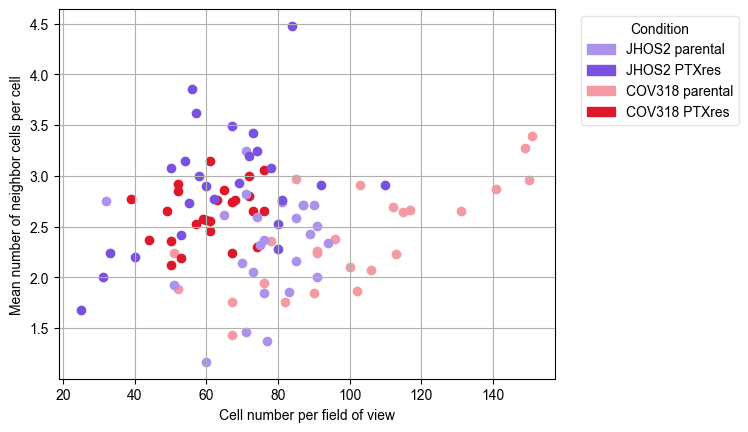

In [30]:
# Prepare data to get the neighbor information for each cell line or field of view
# We tried two settings in cell profiler, one considered only adjacent cells as neighbors, 
# the second considered everything within 20 pixels as neighbor
# this is done on a field of view level
# For AZD treatment
# Define color mappings for conditions
cell_line_colors = {
    "JHOS2 PTXres": "#7b51df",
    "COV318 parental": "#f49aa3",
    "COV318 PTXres": "#de182b",
    "JHOS2 parental": "#ac92eb"
}

custom_order = ["JHOS2 parental", "JHOS2 PTXres",
                "COV318 parental", "COV318 PTXres"
]
sorted_colors = {cond: cell_line_colors[cond] for cond in custom_order}

azd_mask = sel_cell_lines_before["Condition"].isin(custom_order) # Filter by parental and AZD1775
sel_cell_lines_AZD_neighbor = sel_cell_lines_before[azd_mask]

# Prepare data to get the neighbor information for each field of view
# We tried two settings in cell profiler, one considered only adjacent cells as neighbors, 
col_names = ["Condition", "Number of cells", "Number of neighbors per cell", "Total number of neighbors"]       
grouped_c_fov = sel_cell_lines_AZD_neighbor.groupby(["CellLine", "Metadata_Well", "Metadata_Site"])
cell_num_fov = grouped_c_fov.size()
neighbor_num_fov = grouped_c_fov["Neighbors_NumberOfNeighbors_20"].mean() # gets the mean number of neighbor cells
neighbor_sum_fov = grouped_c_fov["Neighbors_NumberOfNeighbors_20"].sum() # gets the sum of neighbor cells in total
conditions = grouped_c_fov["Condition"].first()
int_feat_fov = pd.concat([conditions, cell_num_fov, neighbor_num_fov, neighbor_sum_fov], axis=1, keys=col_names).reset_index()

# Reuse the cell_line_colors dictionary from the previous plots
colors = [cell_line_colors[line] for line in int_feat_fov["Condition"]] # generate a list of colors

sorted_colors = dict(sorted(cell_line_colors.items())) # Sorting cell line colors for legend

for i, (cell_num, neighbor_num, label, color) in enumerate(zip(int_feat_fov["Number of cells"], int_feat_fov["Number of neighbors per cell"], int_feat_fov["Condition"], colors)):
    plt.scatter(cell_num, neighbor_num, c=color)

for label, color in sorted_colors.items(): # Create dummy scatter plot objects with labels for each category for the legend
    plt.scatter([], [], color=color, label=label)

handles=[plt.Rectangle((0,0), 1, 1, color=sorted_colors[key]) for key in custom_order]
plt.legend(handles, custom_order, title="Condition", framealpha=0.5, bbox_to_anchor=(1.04, 1), loc="upper left")
plt.xlabel("Cell number per field of view")
plt.ylabel("Mean number of neighbor cells per cell")
plt.grid(True)
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42
plt.savefig("Number of neighbors over cell number_sel_cell_lines_Adjacent_FOV_mean_PTX.pdf", dpi=300, bbox_inches="tight")
plt.show()

int_feat_fov["Relative number of neighbors over cell number"] = int_feat_fov["Total number of neighbors"]/int_feat_fov["Number of cells"]
int_feat_fov.to_excel("Neighbor cell analysis_PTX treatment.xlsx")